In [ ]:
import pandas as pd
import requests
import io

# Direct URL to a reliable source of the adult dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/adult-all.csv"

# Adding column names manually as the raw CSV might not have them
column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'educational-num',
    'marital-status', 'occupation', 'relationship', 'race', 'gender',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

# Download and load into DataFrame
s = requests.get(url).content
df = pd.read_csv(io.StringIO(s.decode('utf-8')), names=column_names, na_values='?')

# Check if it loaded correctly
print(df.head())
print(f"\nDataset loaded with {df.shape[0]} rows and {df.shape[1]} columns.")

   age         workclass  fnlwgt  education  educational-num  \
0   39         State-gov   77516  Bachelors               13   
1   50  Self-emp-not-inc   83311  Bachelors               13   
2   38           Private  215646    HS-grad                9   
3   53           Private  234721       11th                7   
4   28           Private  338409  Bachelors               13   

       marital-status         occupation   relationship   race  gender  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital-gain  capital-loss  hours-per-week native-country income  
0          2174             0              40  United-States  <=50K  
1             0             0 

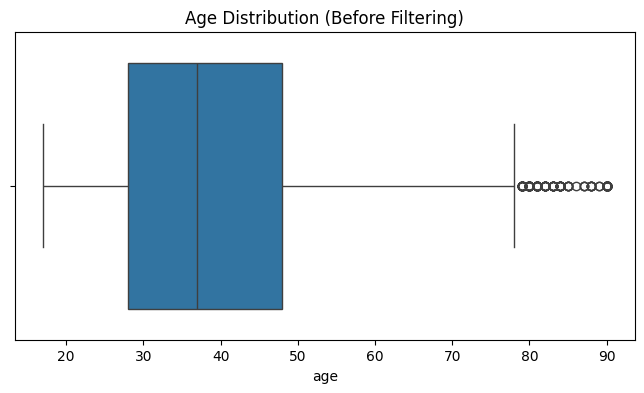

Data shape after cleaning: (48438, 14)


In [ ]:
# 1. Handling Missing Values ('?')
# Since we loaded with na_values='?', they are now 'NaN'. We'll fill them with 'Others'
df = df.fillna('Others')

# 2. Removing irrelevant rows (Never-worked or Without-pay)
df = df[~df['workclass'].isin(['Never-worked', 'Without-pay'])]

# 3. Visualizing Age Outliers before filtering
plt.figure(figsize=(8,4))
sns.boxplot(x=df['age'])
plt.title('Age Distribution (Before Filtering)')
plt.show()

# 4. Filtering Age (Focusing on 17 to 75 years as per session)
df = df[(df['age'] >= 17) & (df['age'] <= 75)]

# 5. Dropping the redundant 'education' column (we have educational-num)
df = df.drop('education', axis=1)

print(f"Data shape after cleaning: {df.shape}")


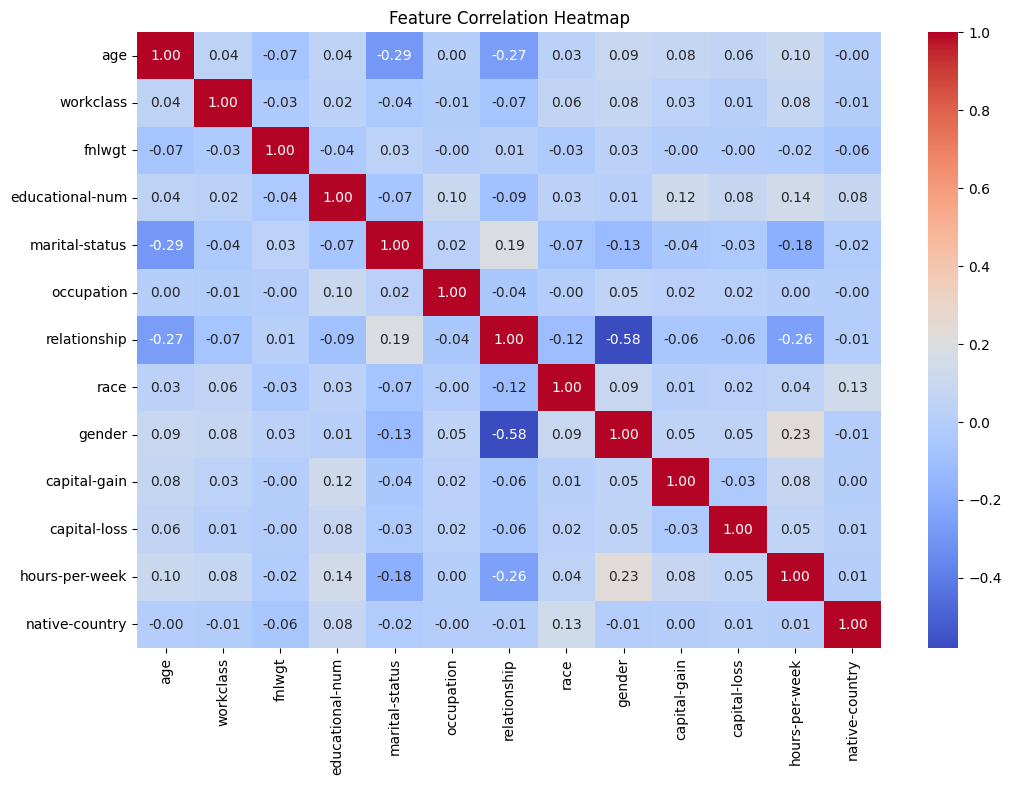

Data is now numerical and scaled. Ready for training!


In [ ]:
# 1. Separate features (X) and target (y)
X = df.drop('income', axis=1)
y = df['income']

# 2. Label Encoding for categorical text columns
le = LabelEncoder()
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = le.fit_transform(X[col])

# Also encode the target 'income' (<=50K becomes 0, >50K becomes 1)
y = le.fit_transform(y)

# 3. Min-Max Scaling for numerical columns
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns)

# 4. Correlation Heatmap (To see which features matter most)
plt.figure(figsize=(12, 8))
sns.heatmap(X.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

print("Data is now numerical and scaled. Ready for training!")

In [ ]:
!pip install gradio


In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import gradio as gr
from IPython.display import clear_output

# 1. DATA PREP (Standard Census Dataset)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
           'occupation', 'relationship', 'race', 'gender', 'capital-gain',
           'capital-loss', 'hours-per-week', 'native-country', 'income']
df = pd.read_csv(url, names=columns, skipinitialspace=True).replace('?', np.nan).dropna()
key_features = ['age', 'workclass', 'education-num', 'marital-status', 'occupation', 'gender', 'hours-per-week']

# 2. ENCODING & MODEL
encoders = {}
for col in ['workclass', 'marital-status', 'occupation', 'gender', 'income']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

X, y = df[key_features], df['income']
model = RandomForestClassifier(n_estimators=100, random_state=42).fit(X, y)

# 3. INDIAN MAPPINGS
edu_map = {"Below 10th": 8, "12th Pass": 9, "Diploma": 10, "B.Tech/B.Sc": 13, "M.Tech/MBA": 14, "CA/MBBS": 15, "PhD": 16}
work_map = {"Private Sector": "Private", "Freelance": "Self-emp-not-inc", "Business Owner": "Self-emp-inc", "Central Govt": "Federal-gov", "State Govt": "State-gov"}
occ_map = {"Admin/Office": "Adm-clerical", "Managerial": "Exec-managerial", "Professional/IT": "Prof-specialty", "Sales/Marketing": "Sales", "Service/Retail": "Other-service", "Technical Support": "Tech-support"}

# 4. PREDICTION LOGIC
def predict(age, work, edu, marital, occ, gender, hours):
    u_work, u_occ = work_map[work], occ_map[occ]
    input_df = pd.DataFrame([[age, u_work, edu_map[edu], marital, u_occ, gender, hours]], columns=key_features)
    for col in ['workclass', 'marital-status', 'occupation', 'gender']:
        input_df[col] = encoders[col].transform(input_df[col])
    res = encoders['income'].inverse_transform(model.predict(input_df))[0]
    return "💰 High Earner (>₹40 LPA)" if res == ">50K" else "📉 Standard Bracket (<₹40 LPA)"

#5. CUSTOM CSS
custom_css = """
/* Force background to fill the whole screen */
.gradio-container {
    background-color: #0b0f19 !important;
    background-image: radial-gradient(circle at center, #1a202c 0%, #0b0f19 100%) !important;
    border: 2px solid #00ffff !important;
    border-radius: 15px !important;
}
/* Style the labels with a neon glow */
label span {
    color: #00ffff !important;
    text-shadow: 0 0 5px #00ffff !important;
    font-weight: bold !important;
}
/* Futuristic Submit Button */
button.primary {
    background: linear-gradient(90deg, #008b8b, #00ffff) !important;
    color: #0b0f19 !important;
    font-weight: bold !important;
    border: none !important;
    box-shadow: 0 0 10px #00ffff !important;
}
"""

# 6. LAUNCH
clear_output()
gr.close_all()
iface = gr.Interface(
    fn=predict,
    inputs=[
        gr.Number(label="Age", value=22),
        gr.Dropdown(choices=list(work_map.keys()), label="Employment Sector"),
        gr.Dropdown(choices=list(edu_map.keys()), label="Education"),
        gr.Dropdown(choices=list(encoders['marital-status'].classes_), label="Marital Status"),
        gr.Dropdown(choices=list(occ_map.keys()), label="Job Role"),
        gr.Dropdown(choices=list(encoders['gender'].classes_), label="Gender"),
        gr.Number(label="Work Hours/Week", value=40)
    ],
    outputs="text",
    title="🚀 AI SALARY PREDICTION ENGINE",
    css=custom_css # This forces the background and colors
)
iface.launch(share=True)

Closing server running on port: 7860
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f2296e5874292f2537.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
